# PyTorch regression: combined cycle power plant

Predict a power plant's net hourly electrical output, **PE (MW)**, from four measured operating conditions. The data come from the [UCI Combined Cycle Power Plant dataset](https://archive.ics.uci.edu/dataset/294/combined%2Bcycle%2Bpower%2Bplant), provided under CC BY 4.0. The accompanying CSV contains **Sheet1 only** from the UCI workbook; its other four sheets repeat these observations in different orders.

| Input | Meaning |
|---|---|
| AT | Ambient temperature (°C) |
| V | Exhaust vacuum (cm Hg) |
| AP | Ambient pressure (mbar) |
| RH | Relative humidity (%) |

This version keeps the earlier **60% training / 20% validation / 20% test** split, a small ReLU network, mini-batch SGD, and MSE reports during training. The random split estimates performance on observations from the same dataset; it is not a future-time forecasting test.

Source rows: 9568; exact duplicates removed: 41
Observations used: 9527


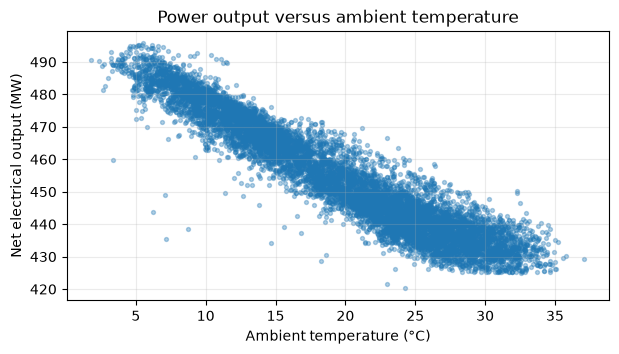

In [46]:
# Read one copy of the data and inspect the target.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

RNG = 10
DATA_PATH = Path("DataVisualization/combined_cycle_power_plant.csv")
raw = pd.read_csv(DATA_PATH)
data = raw.drop_duplicates().reset_index(drop=True)
FEATURES = ["AT", "V", "AP", "RH"]
X = data[FEATURES]          # Keep pandas column names for readable indexing.
y = data[["PE"]]           # Double brackets keep the target two-dimensional.

print(f"Source rows: {len(raw)}; exact duplicates removed: {len(raw) - len(data)}")
print(f"Observations used: {len(data)}")

plt.figure(figsize=(7, 3.5))
plt.scatter(data["AT"], data["PE"], s=8, alpha=0.35)
plt.xlabel("Ambient temperature (°C)")
plt.ylabel("Net electrical output (MW)")
plt.title("Power output versus ambient temperature")
plt.grid(alpha=0.25)
plt.show()


## 1. Split the observations and scale the inputs

Reserve 20% for the final test. Use 25% of the remaining 80% for validation, giving 60/20/20 overall. Fit the input and target scalers on the training set alone. `StandardScaler.transform()` returns NumPy arrays, which PyTorch can convert to tensors; the original `X` and `y` can remain pandas DataFrames.


In [47]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=RNG,
)

x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)
x_train = torch.tensor(x_scaler.transform(X_train), dtype=torch.float32)
y_train_scaled = torch.tensor(y_scaler.transform(y_train), dtype=torch.float32)
x_val = torch.tensor(x_scaler.transform(X_val), dtype=torch.float32)

BATCH_SIZE = 128
EPOCHS = 2000
LEARNING_RATE = 0.001
train_loader = DataLoader(
    TensorDataset(x_train, y_train_scaled),
    batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RNG),
)
print(f"Training: {len(X_train)}  Validation: {len(X_val)}  Test: {len(X_test)}")
print(f"{len(train_loader)} mini-batch updates per epoch")


Training: 5715  Validation: 1906  Test: 1906
45 mini-batch updates per epoch


## 2. Define a small feedforward network

Four input neurons represent the four plant measurements. Two ReLU hidden layers contain 16 and 8 neurons, followed by one output neuron for electrical power.


In [48]:
torch.manual_seed(RNG)
model = nn.Sequential(
    nn.Linear(len(FEATURES), 16), nn.ReLU(),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 1),
)
print(model)


Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


## 3. Train with mini-batch SGD

Each mini-batch produces one weight update. After every epoch, compute training and validation MSE in the original units of MW². Progress is printed every 10 epochs while the cell runs.


Epoch   1/2000: train MSE = 238.70 MW², validation MSE = 245.49 MW²
Epoch  10/2000: train MSE = 18.78 MW², validation MSE = 19.20 MW²
Epoch  20/2000: train MSE = 17.73 MW², validation MSE = 17.95 MW²
Epoch  30/2000: train MSE = 17.41 MW², validation MSE = 17.48 MW²
Epoch  40/2000: train MSE = 17.17 MW², validation MSE = 17.24 MW²
Epoch  50/2000: train MSE = 17.03 MW², validation MSE = 17.12 MW²
Epoch  60/2000: train MSE = 16.92 MW², validation MSE = 16.99 MW²
Epoch  70/2000: train MSE = 16.81 MW², validation MSE = 16.91 MW²
Epoch  80/2000: train MSE = 16.87 MW², validation MSE = 17.05 MW²
Epoch  90/2000: train MSE = 16.67 MW², validation MSE = 16.85 MW²
Epoch 100/2000: train MSE = 16.62 MW², validation MSE = 16.79 MW²
Epoch 110/2000: train MSE = 16.55 MW², validation MSE = 16.70 MW²
Epoch 120/2000: train MSE = 16.47 MW², validation MSE = 16.63 MW²
Epoch 130/2000: train MSE = 16.39 MW², validation MSE = 16.57 MW²
Epoch 140/2000: train MSE = 16.32 MW², validation MSE = 16.54 MW²
Epoch 15

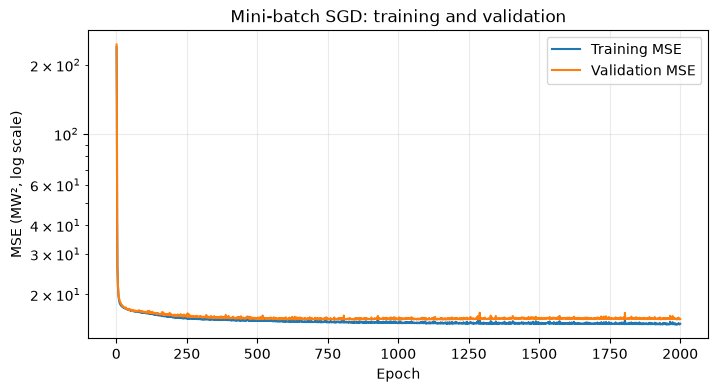

In [49]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
train_mse, val_mse = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = nn.functional.mse_loss(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_pred = y_scaler.inverse_transform(model(x_train).numpy())
        val_pred = y_scaler.inverse_transform(model(x_val).numpy())
    train_mse.append(mean_squared_error(y_train, train_pred))
    val_mse.append(mean_squared_error(y_val, val_pred))

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{EPOCHS}: "
            f"train MSE = {train_mse[-1]:.2f} MW², "
            f"validation MSE = {val_mse[-1]:.2f} MW²",
            flush=True,
        )

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_mse, label="Training MSE")
plt.plot(range(1, EPOCHS + 1), val_mse, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (MW², log scale)")
plt.yscale("log")
plt.title("Mini-batch SGD: training and validation")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Evaluate the untouched test set

Evaluate the model once on test observations. The final plot compares measured and predicted power; points on the diagonal would have zero error.


Final validation MSE: 15.63 MW²
Held-out test MSE:   16.76 MW²


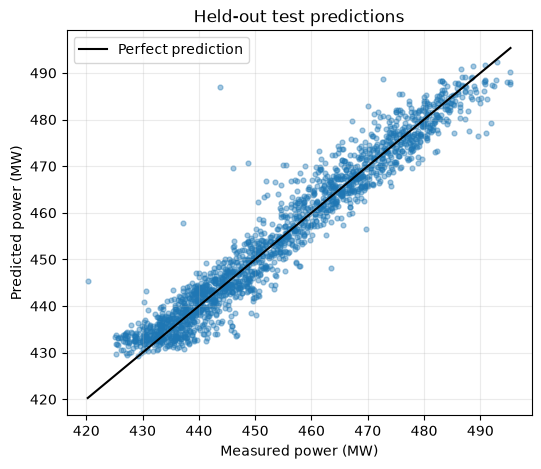

In [50]:
model.eval()
x_test = torch.tensor(x_scaler.transform(X_test), dtype=torch.float32)
with torch.no_grad():
    test_pred = y_scaler.inverse_transform(model(x_test).numpy())
test_mse = mean_squared_error(y_test, test_pred)
print(f"Final validation MSE: {val_mse[-1]:.2f} MW²")
print(f"Held-out test MSE:   {test_mse:.2f} MW²")

limits = [min(y_test["PE"].min(), test_pred.min()),
          max(y_test["PE"].max(), test_pred.max())]
plt.figure(figsize=(6, 5))
plt.scatter(y_test["PE"], test_pred[:, 0], s=12, alpha=0.4)
plt.plot(limits, limits, color="black", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Measured power (MW)")
plt.ylabel("Predicted power (MW)")
plt.title("Held-out test predictions")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
